# ICM612 — Pairs Trading Strategy (Gatev, Goetzmann & Rouwenhorst, 2006)

This notebook walks through the whole pipeline step by step: download data,
screen five candidate pairs, select the three best, backtest a mean-reversion
strategy on two out-of-sample trading periods, and check the results.

**Candidates tested** (one per group member, one per sector):

| Pair | Sector |
|---|---|
| DUK – SO | Utilities |
| VMC – MLM | Construction materials |
| AAPL – MSFT | Mega-cap technology |
| CDNS – SNPS | EDA software |
| JNJ – UNH | Healthcare |

**Timeline:** 5-year formation period (2017–2021) used only to *select*
pairs and estimate parameters, then two 2-year out-of-sample trading
periods (2022–23 and 2024–25) used only to *test* the strategy.

Run this notebook top to bottom in Colab or Jupyter with internet access —
Step 1 needs to reach Yahoo Finance.

## Step 1 — Setup and data download

We download nine years of daily adjusted closing prices (already
dividend/split-adjusted via `auto_adjust=True`) for all ten tickers, plus
trading volume, which we'll need later for the liquidity screen.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf
import statsmodels.api as sm
from statsmodels.tsa.stattools import adfuller, coint

pd.set_option("display.float_format", lambda x: f"{x:.4f}")

PAIRS = {
    "Utilities: DUK-SO":        ("DUK", "SO"),
    "Constr. Materials: VMC-MLM": ("VMC", "MLM"),
    "Mega-cap Tech: AAPL-MSFT": ("AAPL", "MSFT"),
    "EDA Software: CDNS-SNPS":  ("CDNS", "SNPS"),
    "Healthcare: JNJ-UNH":      ("JNJ", "UNH"),
}
TICKERS = sorted({t for pair in PAIRS.values() for t in pair})

START, END = "2017-01-01", "2025-12-31"

In [2]:
close = pd.DataFrame()
volume = pd.DataFrame()

for ticker in TICKERS:
    prices = yf.download(ticker, start=START, end=END, auto_adjust=True, progress=False)
    close[ticker] = prices["Close"].squeeze()
    volume[ticker] = prices["Volume"].squeeze()

close.index = pd.to_datetime(close.index)
volume.index = pd.to_datetime(volume.index)

print(f"Tickers: {TICKERS}")
print(f"Observations: {len(close)}   Range: {close.index[0].date()} to {close.index[-1].date()}")
close.tail()

Tickers: ['AAPL', 'CDNS', 'DUK', 'JNJ', 'MLM', 'MSFT', 'SNPS', 'SO', 'UNH', 'VMC']
Observations: 2261   Range: 2017-01-03 to 2025-12-30


,AAPL,CDNS,DUK,JNJ,MLM,MSFT,SNPS,SO,UNH,VMC
Date,,,,,,,,,,
2025-12-23,271.6207,316.9300,113.8109,202.5226,636.0543,483.7808,475.4700,84.3166,320.4641,291.1653
2025-12-24,273.0667,317.7600,114.4833,204.4909,640.3956,484.9434,475.7500,85.0779,323.2070,291.9608
2025-12-26,272.6578,318.8900,114.1910,204.3433,642.2576,484.6354,477.1400,85.0779,327.4002,292.5175
2025-12-29,273.0169,317.7100,114.5223,204.2744,634.5507,484.0292,478.9700,85.4390,324.5488,290.3500
2025-12-30,272.3387,315.6000,114.6782,203.6346,628.7255,484.4069,474.4900,85.4683,327.7258,287.2280


## Step 2 — Basic data-quality checks

Two quick checks before trusting the data: any missing prices, and any
single-day move bigger than 15% (a common symptom of an unadjusted stock
split or spin-off that slipped through `auto_adjust`). We won't chase every
flag down here — just make sure nothing is silently broken.

In [3]:
daily_returns = close.pct_change()

print("Missing prices per ticker:")
print(close.isna().sum())

print("\nDaily moves larger than 15% (candidate data issues):")
big_moves = daily_returns[(daily_returns.abs() > 0.15)].dropna(how="all")
print(big_moves.dropna(axis=1, how="all"))

Missing prices per ticker:
AAPL    0
CDNS    0
DUK     0
JNJ     0
MLM     0
MSFT    0
SNPS    0
SO      0
UNH     0
VMC     0
dtype: int64

Daily moves larger than 15% (candidate data issues):
             AAPL   CDNS    SNPS     SO     UNH     VMC
Date                                                   
2018-10-23    NaN 0.1537     NaN    NaN     NaN     NaN
2018-10-30    NaN    NaN     NaN    NaN     NaN  0.1749
2020-03-16    NaN    NaN     NaN    NaN -0.1728     NaN
2020-03-17    NaN    NaN     NaN 0.1877     NaN     NaN
2020-03-18    NaN    NaN     NaN    NaN     NaN -0.1761
2020-03-19    NaN    NaN     NaN    NaN     NaN  0.1777
2025-04-09 0.1533    NaN     NaN    NaN     NaN     NaN
2025-04-17    NaN    NaN     NaN    NaN -0.2238     NaN
2025-05-13    NaN    NaN     NaN    NaN -0.1779     NaN
2025-09-10    NaN    NaN -0.3584    NaN     NaN     NaN


These are mostly recognisable market events (the March 2020 Covid crash,
earnings surprises) rather than data errors — worth a one-line note in the
report appendix for each one, but not something to fix in the data itself.

## Step 3 — Split into formation and trading periods

- **Formation period** (2017–2021, 5 years): used only to *select* pairs
  and estimate parameters (hedge ratio, spread mean/std).
- **Trading period 1** (2022–23) and **Trading period 2** (2024–25): used
  only to *test* the strategy out of sample.

The March 2020 crash sits inside the formation period. We keep it in the
baseline (a strategy should be able to handle a real crisis, not just data
with the hard part removed), and re-run the pair-selection step excluding
it as a robustness check further down.

In [4]:
formation = close.loc["2017-01-01":"2021-12-31"]
trading_p1 = close.loc["2022-01-01":"2023-12-31"]
trading_p2 = close.loc["2024-01-01":"2025-12-31"]

print(f"Formation: {len(formation)} obs ({formation.index[0].date()} to {formation.index[-1].date()})")
print(f"TP1:       {len(trading_p1)} obs ({trading_p1.index[0].date()} to {trading_p1.index[-1].date()})")
print(f"TP2:       {len(trading_p2)} obs ({trading_p2.index[0].date()} to {trading_p2.index[-1].date()})")

Formation: 1259 obs (2017-01-03 to 2021-12-31)
TP1:       501 obs (2022-01-03 to 2023-12-29)
TP2:       501 obs (2024-01-02 to 2025-12-30)


## Step 4 — Correlation matrix (first screen)

Correlation is the natural first pass: which candidates move together at
all? It is **not** sufficient on its own — two stocks can be highly
correlated without their spread ever reverting to a stable mean, which is
what pairs trading actually needs. We use it here only to sanity-check the
five hand-picked candidates before running the formal criteria in Step 5.

In [5]:
formation[TICKERS].corr().round(3)

,AAPL,CDNS,DUK,JNJ,MLM,MSFT,SNPS,SO,UNH,VMC
AAPL,1.0000,0.9790,0.8600,0.9310,0.8490,0.9770,0.9850,0.8490,0.9500,0.8290
CDNS,0.9790,1.0000,0.8910,0.9310,0.8670,0.9860,0.9960,0.8720,0.9500,0.8530
DUK,0.8600,0.8910,1.0000,0.8960,0.8450,0.9000,0.8900,0.9420,0.8850,0.8300
JNJ,0.9310,0.9310,0.8960,1.0000,0.7990,0.9360,0.9280,0.8510,0.9380,0.7830
MLM,0.8490,0.8670,0.8450,0.7990,1.0000,0.8480,0.8740,0.8150,0.8380,0.9880
MSFT,0.9770,0.9860,0.9000,0.9360,0.8480,1.0000,0.9880,0.8870,0.9670,0.8290
SNPS,0.9850,0.9960,0.8900,0.9280,0.8740,0.9880,1.0000,0.8730,0.9500,0.8570
SO,0.8490,0.8720,0.9420,0.8510,0.8150,0.8870,0.8730,1.0000,0.8300,0.8080
UNH,0.9500,0.9500,0.8850,0.9380,0.8380,0.9670,0.9500,0.8300,1.0000,0.8140
VMC,0.8290,0.8530,0.8300,0.7830,0.9880,0.8290,0.8570,0.8080,0.8140,1.0000


## Step 5 — The five selection criteria (formation period only)

The brief asks for multiple selection criteria, not cointegration alone.
For each candidate pair we compute:

1. **Liquidity** — minimum average daily dollar volume of the two legs
   (higher is better: the weaker leg shouldn't be hard to trade)
2. **Correlation of daily returns** (higher is better)
3. **Mean absolute spread** — normalise both legs to 1 on day one, take
   `|leg1 - leg2|`, average it (lower is better: a tighter spread)
4. **MSD** (mean squared deviation of that same spread — SSD divided by the
   number of observations; lower is better, same intuition as (3) but
   penalises large deviations more)
5. **Cointegration p-value, worst direction** — the Engle–Granger test can
   give different results depending on which leg you regress on which, so
   we run it both ways and report the *worse* (larger) p-value, a more
   conservative standard (lower p-value is better: it means we can reject
   "no cointegration" with more confidence)

`statsmodels.tsa.stattools.coint` already uses MacKinnon's (2010)
cointegration-specific critical values internally, not the generic
Dickey–Fuller ones — important, because using the wrong critical values
for a residual-based test like this over-rejects the null.

In [6]:
def worst_direction_coint_pvalue(x, y):
    """Engle-Granger test in both directions; return the larger (worse) p-value."""
    _, p_xy, _ = coint(x, y)
    _, p_yx, _ = coint(y, x)
    return max(p_xy, p_yx)


rows = []
for label, (s1, s2) in PAIRS.items():
    norm1 = formation[s1] / formation[s1].iloc[0]
    norm2 = formation[s2] / formation[s2].iloc[0]
    spread = norm1 - norm2

    dollar_vol = (close[[s1, s2]] * volume[[s1, s2]]).loc[formation.index].mean() / 1e6

    rows.append({
        "pair": label,
        "min avg $vol (m)": min(dollar_vol[s1], dollar_vol[s2]),
        "corr (returns)": formation[[s1, s2]].pct_change().corr().iloc[0, 1],
        "mean |spread|": spread.abs().mean(),
        "MSD": (spread ** 2).mean(),
        "EG p (worst dir.)": worst_direction_coint_pvalue(formation[s1], formation[s2]),
    })

criteria = pd.DataFrame(rows).set_index("pair")
criteria

,min avg $vol (m),corr (returns),mean |spread|,MSD,EG p (worst dir.)
pair,,,,,
Utilities: DUK-SO,197.3411,0.8378,0.0769,0.0085,0.3317
Constr. Materials: VMC-MLM,135.4200,0.8714,0.0653,0.0093,0.0119
Mega-cap Tech: AAPL-MSFT,4178.9941,0.7372,0.2786,0.1304,0.2713
EDA Software: CDNS-SNPS,136.0109,0.8446,0.4739,0.3527,0.0017
Healthcare: JNJ-UNH,835.1121,0.5224,0.4884,0.3750,0.0476


## Step 6 — Rank and select the three best pairs

Equal-weighted rank sum across the five criteria (the brief gives no basis
for weighting them differently). Rank 1 = best on that criterion. Lowest
total rank sum wins.

In [7]:
ranks = pd.DataFrame({
    "$vol rank":   criteria["min avg $vol (m)"].rank(ascending=False),
    "corr rank":   criteria["corr (returns)"].rank(ascending=False),
    "spread rank": criteria["mean |spread|"].rank(ascending=True),
    "MSD rank":    criteria["MSD"].rank(ascending=True),
    "EG p rank":   criteria["EG p (worst dir.)"].rank(ascending=True),
})
ranks["rank sum"] = ranks.sum(axis=1)
ranks = ranks.sort_values("rank sum")
ranks

,$vol rank,corr rank,spread rank,MSD rank,EG p rank,rank sum
pair,,,,,,
Constr. Materials: VMC-MLM,5.0000,1.0000,1.0000,2.0000,2.0000,11.0000
Utilities: DUK-SO,3.0000,3.0000,2.0000,1.0000,5.0000,14.0000
Mega-cap Tech: AAPL-MSFT,1.0000,4.0000,3.0000,3.0000,4.0000,15.0000
EDA Software: CDNS-SNPS,4.0000,2.0000,4.0000,4.0000,1.0000,15.0000
Healthcare: JNJ-UNH,2.0000,5.0000,5.0000,5.0000,3.0000,20.0000


In [8]:
SELECTED = list(ranks.index[:3])
print("Selected pairs:", SELECTED)

Selected pairs: ['Constr. Materials: VMC-MLM', 'Utilities: DUK-SO', 'Mega-cap Tech: AAPL-MSFT']


**Tie check:** if two pairs share the same rank sum for third place, the
pre-declared tiebreak is lowest MSD (tighter spread wins). Confirm above
whether a tie applies to your run, and note the tiebreak explicitly in the
report if so.

**Robustness check — does excluding Covid change the answer?** We repeat
Step 5–6 on a formation period with the crisis window removed, and compare.

In [9]:
covid_mask = (formation.index >= "2020-02-15") & (formation.index <= "2020-05-15")
formation_ex_covid = formation.loc[~covid_mask]

rows_ex = []
for label, (s1, s2) in PAIRS.items():
    norm1 = formation_ex_covid[s1] / formation_ex_covid[s1].iloc[0]
    norm2 = formation_ex_covid[s2] / formation_ex_covid[s2].iloc[0]
    spread = norm1 - norm2
    dollar_vol = (close[[s1, s2]] * volume[[s1, s2]]).loc[formation_ex_covid.index].mean() / 1e6
    rows_ex.append({
        "pair": label,
        "min avg $vol (m)": min(dollar_vol[s1], dollar_vol[s2]),
        "corr (returns)": formation_ex_covid[[s1, s2]].pct_change().corr().iloc[0, 1],
        "mean |spread|": spread.abs().mean(),
        "MSD": (spread ** 2).mean(),
        "EG p (worst dir.)": worst_direction_coint_pvalue(formation_ex_covid[s1], formation_ex_covid[s2]),
    })
criteria_ex = pd.DataFrame(rows_ex).set_index("pair")

ranks_ex = pd.DataFrame({
    "$vol rank":   criteria_ex["min avg $vol (m)"].rank(ascending=False),
    "corr rank":   criteria_ex["corr (returns)"].rank(ascending=False),
    "spread rank": criteria_ex["mean |spread|"].rank(ascending=True),
    "MSD rank":    criteria_ex["MSD"].rank(ascending=True),
    "EG p rank":   criteria_ex["EG p (worst dir.)"].rank(ascending=True),
})
ranks_ex["rank sum"] = ranks_ex.sum(axis=1)
SELECTED_EX_COVID = list(ranks_ex.sort_values("rank sum").index[:3])

print("Selected (Covid included):", SELECTED)
print("Selected (Covid excluded):", SELECTED_EX_COVID)
print("Same three pairs:", set(SELECTED) == set(SELECTED_EX_COVID))

Selected (Covid included): ['Constr. Materials: VMC-MLM', 'Utilities: DUK-SO', 'Mega-cap Tech: AAPL-MSFT']
Selected (Covid excluded): ['Constr. Materials: VMC-MLM', 'Utilities: DUK-SO', 'Mega-cap Tech: AAPL-MSFT']
Same three pairs: True


## Step 7 — Formation-period diagnostics for the selected pairs

Two numbers we'll need for the backtest, and that are also worth reporting
in their own right:

- **Hedge ratio** ($\beta$): OLS slope from regressing leg 1 on leg 2 over
  the formation period. The baseline backtest still uses a simple
  dollar-neutral $(1, -1)$ position — this just shows how far that is from
  the statistically "optimal" ratio.
- **Half-life**: how many days it takes a spread to close half the distance
  back to its long-run mean, estimated by fitting
  $\Delta \text{spread}_t = \phi \cdot \text{spread}_{t-1} + \varepsilon_t$
  and computing $-\ln(2)/\ln(1+\phi)$.

In [10]:
for label in SELECTED:
    s1, s2 = PAIRS[label]

    X = sm.add_constant(formation[s2])
    beta = sm.OLS(formation[s1], X).fit().params[s2]

    norm1 = formation[s1] / formation[s1].iloc[0]
    norm2 = formation[s2] / formation[s2].iloc[0]
    spread = norm1 - norm2
    spread_lag = spread.shift(1).dropna()
    spread_diff = spread.diff().dropna()
    phi = sm.OLS(spread_diff, spread_lag.loc[spread_diff.index]).fit().params.iloc[0]
    half_life = -np.log(2) / np.log(1 + phi)

    print(f"{label}: hedge ratio (beta) = {beta:.3f}, half-life = {half_life:.1f} days")

Constr. Materials: VMC-MLM: hedge ratio (beta) = 0.398, half-life = 295.4 days
Utilities: DUK-SO: hedge ratio (beta) = 1.142, half-life = 97.1 days
Mega-cap Tech: AAPL-MSFT: hedge ratio (beta) = 0.531, half-life = 132.7 days


## Step 8 — The trading signal and the backtest engine

For each selected pair, in each trading period:

1. Re-normalise both legs to 1 on the first day of *that* trading period
   (a fresh baseline — the formation-period normalisation doesn't carry
   over).
2. Compute the spread and convert it to a z-score, using the **mean and
   standard deviation from the formation period** (we're not allowed to
   peek at the trading period to set our own thresholds).
3. Enter when $|z| > 2$: short the leg that's outperformed, buy the leg
   that's lagged, one dollar each (self-financing — the short proceeds fund
   the long leg).
4. Exit when $z$ crosses back through 0, or at the end of the period if it
   never converges.

This is the only piece of logic complex enough to be worth a function,
since we call it six times (3 pairs × 2 periods).

In [11]:
def backtest(price_data, formation_spread, s1, s2, entry_z=2.0, exit_z=0.0):
    """Z-score mean-reversion backtest on one pair over one trading period.
    Returns a dict of summary stats plus the daily cumulative P&L series."""
    mu, sigma = formation_spread.mean(), formation_spread.std()

    n1 = price_data[s1] / price_data[s1].iloc[0]
    n2 = price_data[s2] / price_data[s2].iloc[0]
    spread = n1 - n2
    z = (spread - mu) / sigma

    position = 0          # +1 = long spread, -1 = short spread, 0 = flat
    positions = []
    n_trades = 0
    for zi in z:
        if position == 0 and zi > entry_z:
            position, n_trades = -1, n_trades + 1
        elif position == 0 and zi < -entry_z:
            position, n_trades = 1, n_trades + 1
        elif position == 1 and zi >= exit_z:
            position, n_trades = 0, n_trades + 1
        elif position == -1 and zi <= exit_z:
            position, n_trades = 0, n_trades + 1
        positions.append(position)

    # trade on the day AFTER the signal, to avoid look-ahead / bid-ask bounce
    positions = pd.Series(positions, index=z.index).shift(1).fillna(0)
    daily_pnl = positions * (n1.pct_change().fillna(0) - n2.pct_change().fillna(0))
    cum_pnl = daily_pnl.cumsum()

    return {
        "n_trades": n_trades,
        "total_pnl": cum_pnl.iloc[-1],
        "max_drawdown": (cum_pnl - cum_pnl.cummax()).min(),
        "days_in_market": (positions != 0).mean() * 100,
        "open_at_end": positions.iloc[-1] != 0,
        "cum_pnl_series": cum_pnl,
    }

## Step 9 — Run the backtest on Trading Period 1 (2022–23)

In [12]:
formation_spreads = {}
results_p1 = {}
for label in SELECTED:
    s1, s2 = PAIRS[label]
    n1 = formation[s1] / formation[s1].iloc[0]
    n2 = formation[s2] / formation[s2].iloc[0]
    formation_spreads[label] = n1 - n2
    results_p1[label] = backtest(trading_p1, formation_spreads[label], s1, s2)

pd.DataFrame({
    label: {k: v for k, v in r.items() if k != "cum_pnl_series"}
    for label, r in results_p1.items()
}).T

,n_trades,total_pnl,max_drawdown,days_in_market,open_at_end
Constr. Materials: VMC-MLM,0,0.0000,0.0000,0.0000,False
Utilities: DUK-SO,1,0.0831,-0.0622,30.3393,True
Mega-cap Tech: AAPL-MSFT,0,0.0000,0.0000,0.0000,False


## Step 10 — Run the backtest on Trading Period 2 (2024–25), and compare

In [13]:
results_p2 = {}
for label in SELECTED:
    s1, s2 = PAIRS[label]
    results_p2[label] = backtest(trading_p2, formation_spreads[label], s1, s2)

pd.DataFrame({
    label: {k: v for k, v in r.items() if k != "cum_pnl_series"}
    for label, r in results_p2.items()
}).T

,n_trades,total_pnl,max_drawdown,days_in_market,open_at_end
Constr. Materials: VMC-MLM,0,0.0000,0.0000,0.0000,False
Utilities: DUK-SO,0,0.0000,0.0000,0.0000,False
Mega-cap Tech: AAPL-MSFT,0,0.0000,0.0000,0.0000,False


In [14]:
total_p1 = sum(r["total_pnl"] for r in results_p1.values())
total_p2 = sum(r["total_pnl"] for r in results_p2.values())
print(f"Total P&L, 3 pairs, TP1: ${total_p1:.4f}  (${total_p1/3:.4f} per pair)")
print(f"Total P&L, 3 pairs, TP2: ${total_p2:.4f}  (${total_p2/3:.4f} per pair)")
print(f"Change TP1 -> TP2: {100*(total_p2-total_p1)/abs(total_p1):.1f}%")

Total P&L, 3 pairs, TP1: $0.0831  ($0.0277 per pair)
Total P&L, 3 pairs, TP2: $0.0000  ($0.0000 per pair)
Change TP1 -> TP2: -100.0%


## Step 11 — Cumulative return chart

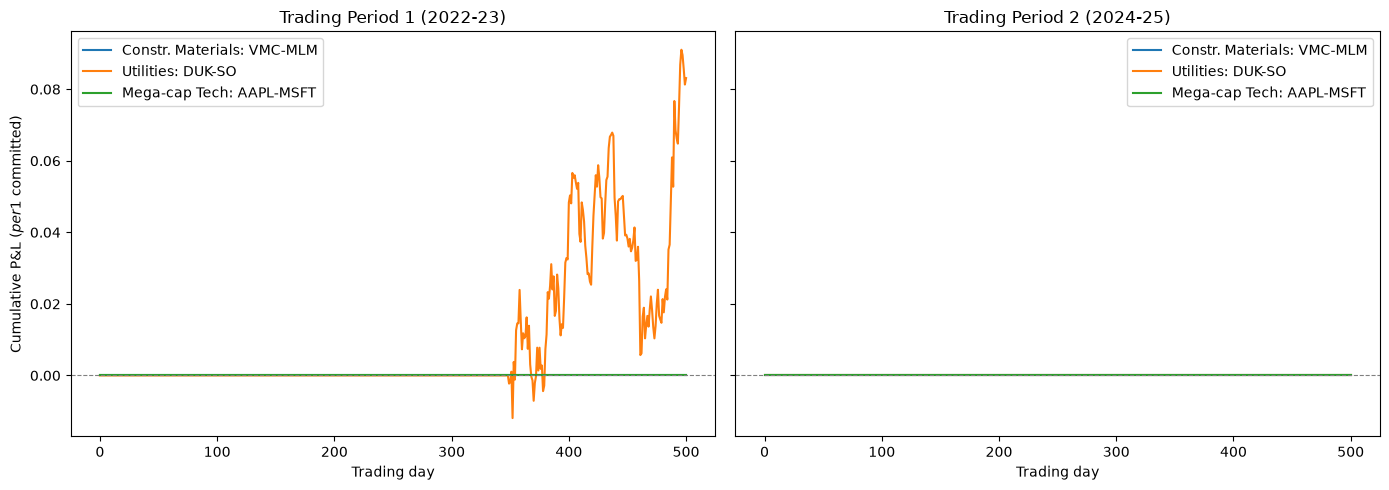

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
for label in SELECTED:
    axes[0].plot(results_p1[label]["cum_pnl_series"].values, label=label)
    axes[1].plot(results_p2[label]["cum_pnl_series"].values, label=label)
axes[0].set_title("Trading Period 1 (2022-23)")
axes[1].set_title("Trading Period 2 (2024-25)")
for ax in axes:
    ax.axhline(0, color="grey", lw=0.8, ls="--")
    ax.legend()
    ax.set_xlabel("Trading day")
axes[0].set_ylabel("Cumulative P&L ($ per $1 committed)")
plt.tight_layout()
plt.show()

## Step 12 — Estimating transaction costs

The backtest above is gross of costs. We don't have real bid-ask spread
data, so we apply a flat, literature-justified assumption — 5 basis points
one-way per leg (Krauss, 2017; Do and Faff, 2010) — to every entry and
exit. Since only one position per pair is open at a time, all but the
final trade in a period must have fully closed (entry + exit = 4 legs);
the final trade only entered if it's still open at period end (2 legs).

In [16]:
TC_BPS = 5

total_cost = 0
for label in SELECTED:
    for period_results in (results_p1[label], results_p2[label]):
        n = period_results["n_trades"]
        if n == 0:
            continue
        closed_trades = n - 1 if period_results["open_at_end"] else n
        open_trades = 1 if period_results["open_at_end"] else 0
        legs = closed_trades * 4 + open_trades * 2
        cost = legs * (TC_BPS / 10000)
        total_cost += cost

gross_total = total_p1 + total_p2
print(f"Estimated total transaction cost: ${total_cost:.4f}")
print(f"Gross profit: ${gross_total:.4f}  ->  Net of estimated costs: ${gross_total - total_cost:.4f}")
print(f"Cost as % of gross profit: {100*total_cost/gross_total:.1f}%")

Estimated total transaction cost: $0.0010
Gross profit: $0.0831  ->  Net of estimated costs: $0.0821
Cost as % of gross profit: 1.2%


## Step 13 — Market-neutrality check

If the strategy is genuinely dollar-neutral, daily P&L shouldn't be
explained by the market's own daily return. We regress each pair's daily
P&L on the S&P 500's daily return and check whether beta is close to zero.

In [17]:
spy = yf.download("SPY", start=START, end=END, auto_adjust=True, progress=False)["Close"].squeeze()
spy_returns = spy.pct_change()

for label in SELECTED:
    for period_name, r in [("TP1", results_p1[label]), ("TP2", results_p2[label])]:
        pnl = r["cum_pnl_series"].diff().fillna(r["cum_pnl_series"].iloc[0])
        aligned = pd.concat([pnl, spy_returns], axis=1, join="inner").dropna()
        aligned.columns = ["pnl", "mkt"]
        X = sm.add_constant(aligned["mkt"])
        model = sm.OLS(aligned["pnl"], X).fit(cov_type="HAC", cov_kwds={"maxlags": 5})
        alpha_bp = model.params["const"] * 10000
        beta = model.params["mkt"]
        print(f"{label} | {period_name}: alpha={alpha_bp:.2f} bp/day (t={model.tvalues['const']:.2f}), "
              f"beta={beta:.3f} (t={model.tvalues['mkt']:.2f})")

Constr. Materials: VMC-MLM | TP1: alpha=0.00 bp/day (t=nan), beta=0.000 (t=nan)
Constr. Materials: VMC-MLM | TP2: alpha=0.00 bp/day (t=nan), beta=0.000 (t=nan)
Utilities: DUK-SO | TP1: alpha=1.66 bp/day (t=1.00), beta=0.000 (t=0.02)
Utilities: DUK-SO | TP2: alpha=0.00 bp/day (t=nan), beta=0.000 (t=nan)
Mega-cap Tech: AAPL-MSFT | TP1: alpha=0.00 bp/day (t=nan), beta=0.000 (t=nan)
Mega-cap Tech: AAPL-MSFT | TP2: alpha=0.00 bp/day (t=nan), beta=0.000 (t=nan)
